<a href="https://colab.research.google.com/github/Timang419/deep-learning-for-mortgage-/blob/main/script6_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Script 6 (FULL DATA) — Monte Carlo Comparison: Pool-Level vs Loan-Level Models

Full-data counterpart of the sample `script6_montecarlo` notebook. It compares
the same 6 models (Pool Baseline / Logistic / MLP, Loan Baseline-MC / Logistic-MC /
MortgageNet-MC) but reads the **full-data** outputs of Script 3 (`models/full_run`)
and Script 5 (`pool_monthly/model_full`) instead of the sample-data outputs.

**What changed vs the sample notebook, and why — see Section 0 and Section 4.**


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE_DIR   = '/content/drive/MyDrive/dissertation'
OUTPUT_DIR = os.path.join(BASE_DIR, 'script6_results_full')
LOAN_HDF5  = os.path.join(BASE_DIR, 'hdf5_full_merged')

# ── Load the month-1 extraction checkpoint ──────────────────────────────────
_npz = np.load(os.path.join(OUTPUT_DIR, 'month1_loan_extract.npz'), allow_pickle=True)
X_loans_raw    = _npz['X_loans_raw']
loan_feat_cols = list(_npz['loan_feat_cols'])
print(f'X_loans_raw shape: {X_loans_raw.shape}')

# ── Load the scaler ──────────────────────────────────────────────────────────
with open(os.path.join(LOAN_HDF5, 'scaler.pkl'), 'rb') as f:
    loaded = pickle.load(f)
loan_scaler = loaded['scaler'] if isinstance(loaded, dict) else loaded

CONTINUOUS_COLS = [
    'Current Actual UPB',
    'Current Loan Delinquency Status',
    'Loan Age',
    'Remaining Months to Legal Maturity',
    'Current Interest Rate',
    'Current Non-Interest Bearing UPB',
    'Current Month Modification Cost',
    'Interest Bearing UPB',
    'Months Since Paid',
    'Cumulative_Mod_Cost_Engineered',
    'D30_count_12m',
    'D60_count_12m',
    'D90plus_count_12m',
    'Credit Score',
    'Mortgage Insurance Percentage',
    'Original Debt-to-Income (DTI) Ratio',
    'Original UPB',
    'Original Loan-to-Value (LTV)',
    'Original Interest Rate',
    'Original Loan Term',
    'CLTV_clean',
]
assert len(CONTINUOUS_COLS) == len(loan_scaler.mean_), \
    f'Expected {len(loan_scaler.mean_)} continuous cols, got {len(CONTINUOUS_COLS)}'
print(f'Continuous cols matched: {len(CONTINUOUS_COLS)} ✓')

# scaler_cols only needs to contain every CONTINUOUS_COLS name somewhere --
# loan_feat_cols already does, so we can reuse it directly here rather than
# re-reading test.h5's full 175-column attrs.
scaler_cols = loan_feat_cols

full_to_scaler = {}
for k, name in enumerate(CONTINUOUS_COLS):
    try:
        full_idx = scaler_cols.index(name)
        full_to_scaler[full_idx] = k
    except ValueError:
        print(f'  [WARN] {name} not found in scaler_cols')
print(f'Mapped {len(full_to_scaler)} / {len(CONTINUOUS_COLS)} features ✓')

def sc_mean_scale(col_name):
    if col_name in scaler_cols:
        full_idx = scaler_cols.index(col_name)
    else:
        matches = [i for i, c in enumerate(scaler_cols) if col_name in c]
        if not matches:
            return None
        if len(matches) > 1:
            print(f'  [WARN] sc_mean_scale("{col_name}") matched {len(matches)} columns: '
                  f'{[scaler_cols[i] for i in matches]} -- using first, VERIFY')
        full_idx = matches[0]
    if full_idx not in full_to_scaler:
        return None
    k = full_to_scaler[full_idx]
    return float(loan_scaler.mean_[k]), float(loan_scaler.scale_[k])

def lc_idx(name):
    if name in loan_feat_cols:
        return loan_feat_cols.index(name)
    matches = [i for i, c in enumerate(loan_feat_cols) if name in c]
    if not matches:
        return None
    if len(matches) > 1:
        print(f'  [WARN] lc_idx("{name}") matched {len(matches)} columns: '
              f'{[loan_feat_cols[i] for i in matches]} -- using first, VERIFY')
    return matches[0]

l_idx = {
    'loan_age'    : lc_idx('Loan Age'),
    'maturity'    : lc_idx('Remaining Months to Legal Maturity'),
    'dq'          : lc_idx('Current Loan Delinquency Status'),
    'msp'         : lc_idx('Months Since Paid'),
    'orig_upb'    : lc_idx('Original UPB'),
    'orig_ir'     : lc_idx('Original Interest Rate'),
    'orig_term'   : lc_idx('Original Loan Term'),
    'curr_upb'    : lc_idx('Current Actual UPB'),
    'ib_upb'      : lc_idx('Interest Bearing UPB'),
    'd30_cnt'     : lc_idx('D30_count_12m'),
    'd60_cnt'     : lc_idx('D60_count_12m'),
    'd90_cnt'     : lc_idx('D90plus_count_12m'),
    'mod_cost'    : lc_idx('Current Month Modification Cost'),
    'cum_mod_cost': lc_idx('Cumulative_Mod_Cost_Engineered'),
}

sc = {}
for k, col_name in {
    'dq'          : 'Current Loan Delinquency Status',
    'msp'         : 'Months Since Paid',
    'orig_upb'    : 'Original UPB',
    'orig_ir'     : 'Original Interest Rate',
    'orig_term'   : 'Original Loan Term',
    'curr_upb'    : 'Current Actual UPB',
    'ib_upb'      : 'Interest Bearing UPB',
    'd30_cnt'     : 'D30_count_12m',
    'd60_cnt'     : 'D60_count_12m',
    'd90_cnt'     : 'D90plus_count_12m',
    'mod_cost'    : 'Current Month Modification Cost',
    'cum_mod_cost': 'Cumulative_Mod_Cost_Engineered',
}.items():
    result = sc_mean_scale(col_name)
    sc[k]  = result
    if result is None:
        print(f'  [INFO] {col_name} not in scaler')

print('Setup complete ✓\n')

# ──────────────────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

N_SAMPLE = 5

# ── A) Full wide table ──────────────────────────────────────────────────────
print('='*70)
print('A) ALL COLUMNS, STANDARDIZED VALUES (scroll right to see all)')
print('='*70)
df_wide = pd.DataFrame(X_loans_raw[:N_SAMPLE], columns=loan_feat_cols)
display(df_wide)

# ── B) Human-readable continuous columns ────────────────────────────────────
print('\n' + '='*70)
print('B) CONTINUOUS COLUMNS, CONVERTED BACK TO REAL-WORLD UNITS')
print('='*70)
readable = {}
for col in CONTINUOUS_COLS:
    idx = lc_idx(col)
    mean, scale = sc_mean_scale(col)
    raw_vals = X_loans_raw[:N_SAMPLE, idx] * scale + mean
    readable[col] = raw_vals
df_readable = pd.DataFrame(readable, index=[f'loan_{i}' for i in range(N_SAMPLE)]).T
display(df_readable)

# ── C) Consistency check ────────────────────────────────────────────────────
print('\n' + '='*70)
print('C) l_idx / sc CONSISTENCY CHECK')
print('='*70)
rows = []
for key, search_term in {
    'loan_age'    : 'Loan Age',
    'maturity'    : 'Remaining Months to Legal Maturity',
    'dq'          : 'Current Loan Delinquency Status',
    'msp'         : 'Months Since Paid',
    'orig_upb'    : 'Original UPB',
    'orig_ir'     : 'Original Interest Rate',
    'orig_term'   : 'Original Loan Term',
    'curr_upb'    : 'Current Actual UPB',
    'ib_upb'      : 'Interest Bearing UPB',
    'd30_cnt'     : 'D30_count_12m',
    'd60_cnt'     : 'D60_count_12m',
    'd90_cnt'     : 'D90plus_count_12m',
    'mod_cost'    : 'Current Month Modification Cost',
    'cum_mod_cost': 'Cumulative_Mod_Cost_Engineered',
}.items():
    resolved_idx  = l_idx.get(key)
    resolved_name = loan_feat_cols[resolved_idx] if resolved_idx is not None else None
    exact_match   = (resolved_name == search_term)
    sc_pair       = sc.get(key)
    rows.append({
        'key': key, 'searched_for': search_term,
        'resolved_idx': resolved_idx, 'resolved_name': resolved_name,
        'NAME_MATCHES?': '✓' if exact_match else '✗ MISMATCH',
        'sc_mean': round(sc_pair[0], 2) if sc_pair else None,
        'sc_scale': round(sc_pair[1], 2) if sc_pair else None,
    })
df_check = pd.DataFrame(rows)
display(df_check)

n_bad = (df_check['NAME_MATCHES?'] != '✓').sum()
print(f"\n{'ALL CLEAR ✓' if n_bad == 0 else f'{n_bad} MISMATCH(ES) FOUND — see table above'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_loans_raw shape: (7974848, 174)
Continuous cols matched: 21 ✓
Mapped 21 / 21 features ✓
Setup complete ✓

A) ALL COLUMNS, STANDARDIZED VALUES (scroll right to see all)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Remaining Months to Legal Maturity,Current Interest Rate,Current Non-Interest Bearing UPB,Delinquency Due to Disaster,Current Month Modification Cost,Interest Bearing UPB,mod_flag_N,mod_flag_P,mod_flag_Y,Months Since Paid,step_mod_N,step_mod_None,step_mod_Y,deferral_N,deferral_P,deferral_Y,assist_F,assist_None,assist_R,assist_T,Cumulative_Mod_Cost_Engineered,D30_count_12m,D60_count_12m,D90plus_count_12m,state_0,state_1,state_2,state_3,state_4,Credit Score,MSA,Mortgage Insurance Percentage,Original Debt-to-Income (DTI) Ratio,Original UPB,Original Loan-to-Value (LTV),Original Interest Rate,Prepayment Penalty Mortgage (PPM) Flag,Original Loan Term,Super Conforming Flag,HARP Indicator,Interest Only (I/O) Indicator,MI_OUT_OF_RANGE,CLTV_MISSING,CLTV_clean,DTI_MISSING,FTHB_N,FTHB_Y,FTHB_9,UNITS_1,UNITS_2,UNITS_3,UNITS_4,UNITS_99,OCC_P,OCC_I,OCC_S,OCC_9,CHAN_R,CHAN_9,CHAN_B,CHAN_C,CHAN_T,PROP_SF,PROP_99,PROP_CO,PROP_CP,PROP_MH,PROP_PU,PURP_P,PURP_9,PURP_C,PURP_N,PURP_R,BORR_Single,BORR_Multiple,BORR_Missing,PROG_9,PROG_F,PROG_H,PROG_R,VAL_2,VAL_1,VAL_3,VAL_4,VAL_7,MI_CANCEL_7,MI_CANCEL_N,MI_CANCEL_Y,MI_CANCEL_9,STATE_AK,STATE_AL,STATE_AR,STATE_AZ,STATE_CA,STATE_CO,STATE_CT,STATE_DC,STATE_DE,STATE_FL,STATE_GA,STATE_GU,STATE_HI,STATE_IA,STATE_ID,STATE_IL,STATE_IN,STATE_KS,STATE_KY,STATE_LA,STATE_MA,STATE_MD,STATE_ME,STATE_MI,STATE_MN,STATE_MO,STATE_MS,STATE_MT,STATE_NC,STATE_ND,STATE_NE,STATE_NH,STATE_NJ,STATE_NM,STATE_NV,STATE_NY,STATE_OH,STATE_OK,STATE_OR,STATE_PA,STATE_PR,STATE_RI,STATE_SC,STATE_SD,STATE_TN,STATE_TX,STATE_UT,STATE_VA,STATE_VI,STATE_VT,STATE_WA,STATE_WI,STATE_WV,STATE_WY,STATE_OTHER,VINT_1999,VINT_2000,VINT_2001,VINT_2002,VINT_2003,VINT_2004,VINT_2005,VINT_2006,VINT_2007,VINT_2008,VINT_2009,VINT_2010,VINT_2011,VINT_2012,VINT_2013,VINT_2014,VINT_2015,VINT_2016,VINT_2017,VINT_2018,VINT_2019,VINT_2020,VINT_2021,VINT_2022,VINT_2023,VINT_2024,VINT_2025
0,2.444206,-0.085275,-1.144189,1.085948,-2.226864,-0.034827,0.0,-0.073166,2.447498,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.061887,-0.172978,-0.103389,-0.106973,1.0,0.0,0.0,0.0,0.0,-0.284509,1.0,3.140481,1.095971,2.258666,1.321995,-2.286313,0.0,0.772204,0.0,0.0,0.0,0.0,0.0,1.194363,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.241346,-0.085275,-1.144189,1.085948,0.853127,-0.034827,0.0,-0.073166,1.243534,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.061887,-0.172978,-0.103389,-0.106973,1.0,0.0,0.0,0.0,0.0,0.263836,1.0,-0.376295,0.395627,1.062301,-0.218206,0.845953,0.0,0.772204,0.0,0.0,0.0,0.0,0.0,-0.278227,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.199584,-0.085275,-1.144189,1.085948,-2.331502,-0.034827,0.0,-0.073166,0.200816,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.061887,-0.172978,-0.103389,-0.106973,1.0,0.0,0.0,0.0,0.0,-0.321066,1.0,-0.376295,-1.005062,0.026164,-1.604386,-2.392727,0.0,0.772204,0.0,0.0,0.0,0.0,0.0,-1.603557,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


B) CONTINUOUS COLUMNS, CONVERTED BACK TO REAL-WORLD UNITS


,loan_0,loan_1,loan_2,loan_3,loan_4
Current Actual UPB,372000.000000,2.600000e+05,1.630000e+05,1.690000e+05,1.690000e+05
Current Loan Delinquency Status,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Loan Age,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Remaining Months to Legal Maturity,360.000000,3.600000e+02,3.600000e+02,3.600000e+02,3.600000e+02
Current Interest Rate,2.990000,6.375000e+00,2.875000e+00,6.500000e+00,4.250000e+00
Current Non-Interest Bearing UPB,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Current Month Modification Cost,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Interest Bearing UPB,372000.000000,2.600000e+05,1.630000e+05,1.690000e+05,1.690000e+05
Months Since Paid,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Cumulative_Mod_Cost_Engineered,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00



C) l_idx / sc CONSISTENCY CHECK


,key,searched_for,resolved_idx,resolved_name,NAME_MATCHES?,sc_mean,sc_scale
0,loan_age,Loan Age,2,Loan Age,✓,NaN,NaN
1,maturity,Remaining Months to Legal ...,3,Remaining Months to Legal ...,✓,NaN,NaN
2,dq,Current Loan Delinquency S...,1,Current Loan Delinquency S...,✓,0.16,1.88
3,msp,Months Since Paid,12,Months Since Paid,✓,0.00,1.00
4,orig_upb,Original UPB,36,Original UPB,✓,160550.64,93616.92
5,orig_ir,Original Interest Rate,38,Original Interest Rate,✓,5.46,1.08
6,orig_term,Original Loan Term,40,Original Loan Term,✓,293.77,85.76
7,curr_upb,Current Actual UPB,0,Current Actual UPB,✓,144416.42,93111.47
8,ib_upb,Interest Bearing UPB,8,Interest Bearing UPB,✓,144318.91,93026.06
9,d30_cnt,D30_count_12m,24,D30_count_12m,✓,0.14,0.78



ALL CLEAR ✓


In [ ]:
import numpy as np
d = np.load('/content/drive/MyDrive/dissertation/script6_results_full/script6_predictions_full.npz')
print('Actual PaidOff   :', d['y_true'][:, 6].mean())
print('Logistic MC      :', d['mc_log_preds'][:, 6].mean())
print('MLP MC           :', d['mc_mlp_preds'][:, 6].mean())

Actual PaidOff   : 0.051302265
Logistic MC      : 0.09576811
MLP MC           : 0.121881336


In [ ]:
!pip install hdf5plugin --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 MB 53.7 MB/s eta 0:00:00


In [ ]:
import os, gc, json, pickle, warnings, time, threading, shutil
import numpy as np
import pandas as pd
import h5py, hdf5plugin
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


In [ ]:
SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f'Device: {DEVICE}')


Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


## Section 0 — Paths & What's Different From the Sample-Data Script 6

| Item | Sample script6 (old) | This notebook (full data) |
|---|---|---|
| Loan HDF5 dir   | `hdf5_sample_fullmerged` | `hdf5_full_merged` — Script 3-full's `DRIVE_HDF5` |
| Loan model dir  | `models/wrong_test`      | `models/full_run` — Script 3-full's `OUTPUT_DIR` |
| Pool model dir  | `pool_monthly/model`     | `pool_monthly/model_full` — Script 5-full's `OUTPUT_DIR` |
| Pool panel dir  | `pool_monthly`           | unchanged — Script 4 already built the full panel; the sample notebook was already reusing it |
| `loan_to_pool_mapping.csv` | unchanged | unchanged — also already full-scale |

**Why month-1 extraction is rewritten (Section 4):** `script2_standardize_full.py`
fully row-shuffles `test.h5` (`shuffle_hdf5_chunked`), unlike whatever the sample
pipeline did. The sample notebook's "sort by row index, take the first row per
loan = Loan Age 1" trick relies on row order matching chronological order — that
assumption is **silently false** for the full `test.h5`. The fix here scans for the
row with the **minimum `Loan Age`** per loan, which is correct regardless of row
order, and works for the sample data too.

**Why there's no prefetcher / background thread here, unlike Script 3:** the
`ChunkPrefetcher` in Script 3 hides chunk-load latency behind GPU compute across
**many training epochs** — the cost of loading is amortised over repeated reuse.
Script 6 does a **single one-shot pass** over `test.h5` (to find month-1 rows) and
then runs the Monte Carlo rollout on the small extracted array — there's no
repeated re-reading to hide latency behind, so a background prefetch thread
wouldn't help. The extraction below is a plain sequential chunked scan instead.
For the data volume alone, a single pass doesn't *need* a local copy the way
Script 3/5's many-epoch training does — but Google Drive's FUSE mount adds
real per-request latency to the many small chunked reads underneath each
"5M row" slice (the file is internally chunked at ~10,000 rows/block), so a
single bulk sequential `shutil.copy2` to a fast local disk can still end up
faster overall than streaming chunked reads through the Drive mount, even
counting the extra write+reread. If you have a dedicated local-scratch disk
with room (this notebook defaults to `/mnt/local-scratch`, matching Script
3-full's convention), it's worth using it. Set `COPY_TEST_LOCALLY = False`
below to read straight off Drive instead if you'd rather skip the copy.


In [ ]:
BASE_DIR   = '/content/drive/MyDrive/dissertation'
POOL_DIR   = os.path.join(BASE_DIR, 'pool_monthly')             # Script 4/5 outputs (already full-scale)
MODEL_DIR  = os.path.join(POOL_DIR, 'model_full')                # Script 5-full weights
LOAN_HDF5  = os.path.join(BASE_DIR, 'hdf5_full_merged')          # Script 2-full outputs
LOAN_MODEL = os.path.join(BASE_DIR, 'models', 'full_run')        # Script 3-full weights
OUTPUT_DIR = os.path.join(BASE_DIR, 'script6_results_full')
os.makedirs(OUTPUT_DIR, exist_ok=True)


# BASE_DIR   = '/content/drive/MyDrive/dissertation'
# POOL_DIR   = os.path.join(BASE_DIR, 'pool_monthly',"sample")             # unchanged — single canonical panel
# MODEL_DIR  = os.path.join(BASE_DIR, 'pool_monthly', 'model')                    # CHANGED: 'model' not 'model_full' — sample pool weights
# LOAN_HDF5  = os.path.join(BASE_DIR, 'hdf5_sample_fullmerged')   # CHANGED: sample loan data
# LOAN_MODEL = os.path.join(BASE_DIR, 'models', 'wrong_test')      # CHANGED: sample loan model
# OUTPUT_DIR = os.path.join(BASE_DIR, 'script6_results_sample_correct')   # CHANGED — see below, important
# os.makedirs(OUTPUT_DIR, exist_ok=True)


# LOCAL_DIR = '/mnt/local-scratch/script6'
# os.makedirs(LOCAL_DIR, exist_ok=True)
# COPY_TEST_LOCALLY = False

# for name, p in [('POOL_DIR', POOL_DIR), ('MODEL_DIR', MODEL_DIR),
#                 ('LOAN_HDF5', LOAN_HDF5), ('LOAN_MODEL', LOAN_MODEL)]:
#     exists = '✓' if os.path.exists(p) else '✗ NOT FOUND'
#     print(f'  {name:12s}: {p}  {exists}')

# Only used if you opt in to local-copying test.h5 (see Section 4 note above).
# Dedicated local-scratch disk (matches Script 3-full's convention) -- on
# Colab Pro+ this is a separate disk from the main /content disk, check your
# resource panel (3-dot menu -> "View resources") for its size/mount path and
# adjust LOCAL_DIR if yours differs.
LOCAL_DIR = '/mnt/local-scratch/script6'
os.makedirs(LOCAL_DIR, exist_ok=True)
COPY_TEST_LOCALLY = True   # set False to stream chunked reads straight off Drive instead

for name, p in [('POOL_DIR', POOL_DIR), ('MODEL_DIR', MODEL_DIR),
                ('LOAN_HDF5', LOAN_HDF5), ('LOAN_MODEL', LOAN_MODEL)]:
    exists = '\u2713' if os.path.exists(p) else '\u2717 NOT FOUND'
    print(f'  {name:12s}: {p}  {exists}')


  POOL_DIR    : /content/drive/MyDrive/dissertation/pool_monthly  ✓
  MODEL_DIR   : /content/drive/MyDrive/dissertation/pool_monthly/model_full  ✓
  LOAN_HDF5   : /content/drive/MyDrive/dissertation/hdf5_full_merged  ✓
  LOAN_MODEL  : /content/drive/MyDrive/dissertation/models/full_run  ✓


In [ ]:
N_MC_PATHS  = 1000       # increase to 1000 for the final run
HORIZON     = 12
POOL_SIZE   = 100         # must match Script 4
MC_BATCH    = 16384        # loans per MC batch.
                          # Full data has far more test loans than the sample run,
                          # so MC_BATCH needs to be much larger than the sample's 256
                          # or the python-level loop (n_loans / MC_BATCH iterations)
                          # dominates wall-clock time. Each loan x path combination
                          # is tiny (174 floats), so VRAM headroom is not the binding
                          # constraint here — tune up if GPU utilisation looks low
                          # during run_loan_mc, tune down if you hit OOM.
EXTRACT_CHUNK_ROWS = 5_000_000   # rows per chunk for the month-1 scan (Section 4)

STATE_NAMES = ['current', 'd30', 'd60', 'd90p', 'foreclosure', 'reo', 'paidoff']
FRAC_COLS   = [f'frac_{s}' for s in STATE_NAMES]
N_STATES    = 7
PAIDOFF_CLASS = STATE_NAMES.index('paidoff')   # = 6
print(f'N_MC_PATHS={N_MC_PATHS}  HORIZON={HORIZON}  POOL_SIZE={POOL_SIZE}  MC_BATCH={MC_BATCH}')
print(f'STATE_NAMES: {STATE_NAMES}')


N_MC_PATHS=1000  HORIZON=12  POOL_SIZE=100  MC_BATCH=16384
STATE_NAMES: ['current', 'd30', 'd60', 'd90p', 'foreclosure', 'reo', 'paidoff']


## Section 1 — Architecture Definitions

In [ ]:
class MortgageNet(nn.Module):
    """Loan-level model (Script 3). depth=0 -> logistic; depth>0 -> MLP."""
    def __init__(self, input_dim, num_classes=7,
                 depth=5, hidden_dim=256, dropout_rate=0.3, norm_type='batch'):
        super().__init__()
        layers, d = [], input_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, hidden_dim))
            if norm_type == 'batch':
                layers.append(nn.BatchNorm1d(hidden_dim))
            elif norm_type == 'layer':
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout_rate))
            d = hidden_dim
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer  = nn.Linear(d, num_classes)

    def forward(self, x):
        return self.output_layer(self.hidden_layers(x))


class PoolNet(nn.Module):
    """Pool-level model (Script 5). num_classes=7 for 7-state transitions."""
    def __init__(self, input_dim, num_classes=7,
                 depth=2, hidden_dim=128,
                 dropout_rate=0.3, norm_type='batch'):
        super().__init__()
        layers, d = [], input_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, hidden_dim))
            if norm_type == 'batch':
                layers.append(nn.BatchNorm1d(hidden_dim))
            elif norm_type == 'layer':
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(p=dropout_rate))
            d = hidden_dim
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer  = nn.Linear(d, num_classes)

    def forward(self, x):
        return self.output_layer(self.hidden_layers(x))


print('MortgageNet and PoolNet defined (num_classes=7)')


MortgageNet and PoolNet defined (num_classes=7)


## Section 2 — Load Panel Test Data (Ground Truth at Month 12)

Unchanged from the sample notebook: `panel_test.h5` is ~2.4GB (3.42M rows x 178 features), small enough to load whole, like Script 5.

In [ ]:
print('='*60)
print('STEP 1: Load panel test data')
print('='*60)

with h5py.File(os.path.join(POOL_DIR, 'panel_test.h5'), 'r') as f:
    X_panel_all    = f['X'][:]
    y_panel_all    = f['y'][:]
    pool_ids_all   = f['pool_ids'][:]
    rp_months_all  = f['Reporting_Period_Int'][:]
    panel_feat_cols = [c.decode('utf-8') if isinstance(c, bytes) else c
                       for c in f['X'].attrs['col_names']]
    panel_tgt_cols  = [c.decode('utf-8') if isinstance(c, bytes) else c
                       for c in f['y'].attrs['col_names']]

N_PANEL_FEATS = X_panel_all.shape[1]
print(f'Panel rows     : {len(X_panel_all):,}')
print(f'Panel features : {N_PANEL_FEATS}')
print(f'Target cols    : {panel_tgt_cols}')
print(f'Pool ID range  : {pool_ids_all.min()} \u2013 {pool_ids_all.max()}')

expected_tgt = [f'target_{s}' for s in STATE_NAMES]
assert panel_tgt_cols == expected_tgt, \
    f'Target mismatch!\n  got:      {panel_tgt_cols}\n  expected: {expected_tgt}'
print('Target column order: \u2713')


STEP 1: Load panel test data
Panel rows     : 3,418,914
Panel features : 178
Target cols    : ['target_current', 'target_d30', 'target_d60', 'target_d90p', 'target_foreclosure', 'target_reo', 'target_paidoff']
Pool ID range  : 389642 – 479052
Target column order: ✓


In [ ]:
frac_indices = {}
for s in STATE_NAMES:
    col = f'frac_{s}'
    if col in panel_feat_cols:
        frac_indices[col] = panel_feat_cols.index(col)
    else:
        print(f'  [WARN] {col} not in panel features')
print(f'frac_* found: {list(frac_indices.keys())}')

df_panel = pd.DataFrame({
    'row_idx' : np.arange(len(pool_ids_all)),
    'pool_id' : pool_ids_all.astype(int),
    'rp'      : rp_months_all,
}).sort_values(['pool_id', 'rp']).reset_index(drop=True)

pool_counts = df_panel.groupby('pool_id')['row_idx'].count()
valid_pools = pool_counts[pool_counts >= HORIZON].index
print(f'Pools with >=12 months: {len(valid_pools):,} / {pool_counts.shape[0]:,}')

df_valid = df_panel[df_panel['pool_id'].isin(valid_pools)].copy()

pool_m1_idx  = {}
pool_m11_idx = {}
for pid, grp in df_valid.groupby('pool_id'):
    rows = grp['row_idx'].values
    if len(rows) >= HORIZON:
        pid_key = int(pid)
        pool_m1_idx[pid_key]  = int(rows[0])
        pool_m11_idx[pid_key] = int(rows[HORIZON - 2])

valid_pool_list = sorted(pool_m1_idx.keys())
N_TEST_POOLS    = len(valid_pool_list)

X_pool_month1  = np.stack([X_panel_all[pool_m1_idx[p]]  for p in valid_pool_list])
y_true_month12 = np.stack([y_panel_all[pool_m11_idx[p]] for p in valid_pool_list])

print(f'\nValid test pools      : {N_TEST_POOLS:,}')
print(f'X_pool_month1  shape  : {X_pool_month1.shape}')
print(f'y_true_month12 shape  : {y_true_month12.shape}')
print(f'Row sum check         : min={y_true_month12.sum(1).min():.4f}  '
      f'max={y_true_month12.sum(1).max():.4f}')
print('\nGround truth avg rates:')
for i, s in enumerate(STATE_NAMES):
    print(f'  {s:15s}: {y_true_month12[:, i].mean():.5f}')


frac_* found: ['frac_current', 'frac_d30', 'frac_d60', 'frac_d90p', 'frac_foreclosure', 'frac_reo', 'frac_paidoff']
Pools with >=12 months: 79,815 / 89,402

Valid test pools      : 79,815
X_pool_month1  shape  : (79815, 178)
y_true_month12 shape  : (79815, 7)
Row sum check         : min=1.0000  max=1.0000

Ground truth avg rates:
  current        : 0.93935
  d30            : 0.00559
  d60            : 0.00121
  d90p           : 0.00148
  foreclosure    : 0.00106
  reo            : 0.00001
  paidoff        : 0.05130


## Section 3 — Load Panel Scaler and Pool Models

In [ ]:
print('='*60)
print('STEP 2: Load panel scaler')
print('='*60)

with open(os.path.join(POOL_DIR, 'panel_scaler.pkl'), 'rb') as f:
    scaler_pkg    = pickle.load(f)
panel_scaler   = scaler_pkg['scaler']
panel_cont_idx = scaler_pkg['cont_idx']

panel_mean  = np.zeros(N_PANEL_FEATS, dtype=np.float64)
panel_scale = np.ones(N_PANEL_FEATS,  dtype=np.float64)
for k, ci in enumerate(panel_cont_idx):
    panel_mean[ci]  = panel_scaler.mean_[k]
    panel_scale[ci] = panel_scaler.scale_[k]

print(f'Continuous features : {len(panel_cont_idx)}')
print(f'Binary features     : {N_PANEL_FEATS - len(panel_cont_idx)}')

p_idx = {}
for col in ['Original UPB', 'Original Interest Rate', 'Original Loan Term',
            'Current Actual UPB', 'Interest Bearing UPB',
            'Loan Age', 'Remaining Months to Legal Maturity',
            'Months Since Paid', 'D30_count_12m', 'D60_count_12m',
            'D90plus_count_12m', 'frac_active', 'frac_observed']:
    if col in panel_feat_cols:
        p_idx[col] = panel_feat_cols.index(col)
    else:
        print(f'  [INFO] panel col not found: {col}')

p_idx_frac = {f'frac_{s}': panel_feat_cols.index(f'frac_{s}')
              for s in STATE_NAMES if f'frac_{s}' in panel_feat_cols}

print(f'\nKey panel indices found: {len(p_idx)} static + {len(p_idx_frac)} frac_*')


STEP 2: Load panel scaler
Continuous features : 21
Binary features     : 157

Key panel indices found: 13 static + 7 frac_*


In [ ]:
print('='*60)
print('STEP 3: Load pool models (Script 5 — full data)')
print('='*60)

log_pool_ckpt = torch.load(
    os.path.join(MODEL_DIR, 'panel_logistic_best.pt'), map_location=DEVICE)
print('Pool logistic checkpoint keys:', list(log_pool_ckpt.keys()))

pool_log_model = PoolNet(
    input_dim=N_PANEL_FEATS, num_classes=N_STATES,
    depth=0, hidden_dim=1, dropout_rate=0.0, norm_type='none').to(DEVICE)
pool_log_model.load_state_dict(log_pool_ckpt['model_state_dict'])
pool_log_model.eval()
print(f'Pool logistic : {sum(p.numel() for p in pool_log_model.parameters()):,} params  \u2713')

mlp_pool_ckpt = torch.load(
    os.path.join(MODEL_DIR, 'panel_mlp_best.pt'), map_location=DEVICE)
print('Pool MLP checkpoint keys     :', list(mlp_pool_ckpt.keys()))

cfg_p = mlp_pool_ckpt['hpo_params']
pool_mlp_model = PoolNet(
    input_dim=N_PANEL_FEATS, num_classes=N_STATES,
    depth=cfg_p['depth'], hidden_dim=cfg_p['hidden_dim'],
    dropout_rate=cfg_p['dropout'], norm_type=cfg_p['norm_type']).to(DEVICE)
pool_mlp_model.load_state_dict(mlp_pool_ckpt['model_state_dict'])
pool_mlp_model.eval()
print(f'Pool MLP      : {sum(p.numel() for p in pool_mlp_model.parameters()):,} params  \u2713')
print(f'Pool MLP cfg  : {cfg_p}')


STEP 3: Load pool models (Script 5 — full data)
Pool logistic checkpoint keys: ['model_state_dict', 'model_class', 'depth', 'num_classes', 'n_features', 'best_lr', 'best_wd', 'best_val_ce', 'state_names', 'target_names', 'feature_cols']
Pool logistic : 1,253 params  ✓
Pool MLP checkpoint keys     : ['model_state_dict', 'model_class', 'num_classes', 'n_features', 'depth', 'hidden_dim', 'dropout_rate', 'norm_type', 'hpo_params', 'state_names', 'target_names', 'feature_cols']
Pool MLP      : 247,047 params  ✓
Pool MLP cfg  : {'depth': 4, 'hidden_dim': 256, 'dropout': 0.3, 'norm_type': 'batch', 'lr': 0.004750747231574268, 'weight_decay': 5.7786871933277145e-05}


## Section 4 — Month-1 Loan Feature Extraction (Full-Data Rewrite)

**This is the section that actually differs in approach, not just paths.**

The sample notebook built `X_loans_raw` by taking the first row (by HDF5 row
index) per loan from `test.h5`, assuming row order = chronological order. The
full `test.h5` has been globally shuffled, so that assumption is wrong here.

Instead: build the target loan set from `loan_to_pool_mapping.csv` (restricted
to pools in the test fold), then do **one sequential chunked pass** over the
full `test.h5`, tracking the row with the **minimum `Loan Age`** seen so far per
target loan. This is correct regardless of row order, costs one read of the file
(no copy, no second pass), and the result is checkpointed to disk so a crash
mid-pipeline doesn't force re-scanning the full file.

Peak extra RAM: one float32 row (174 floats \u2248 700 bytes) per matched loan,
held until a lower-`Loan Age` row is seen for that loan. For ~10\u201320M test loans
that's on the order of 10\u201315GB — fine on a Colab High-RAM runtime, but worth
knowing if you're on a smaller instance.


In [ ]:
print('='*60)
print('STEP 4: Build loan -> pool target set (Script 4 mapping)')
print('='*60)

mapping_path = os.path.join(POOL_DIR, 'loan_to_pool_mapping.csv')
df_mapping   = pd.read_csv(mapping_path)
print(f'Mapping entries      : {len(df_mapping):,}')
print(f'Mapping columns      : {list(df_mapping.columns)}')

valid_pool_set = set(valid_pool_list)
df_map_valid   = df_mapping[df_mapping['pool_id'].isin(valid_pool_set)].copy()
loan_id_col    = 'Loan Sequence Number' if 'Loan Sequence Number' in df_map_valid.columns \
                 else df_map_valid.columns[0]
df_map_valid[loan_id_col] = df_map_valid[loan_id_col].astype(str)

loan_to_pool = dict(zip(df_map_valid[loan_id_col], df_map_valid['pool_id']))
print(f'Target loans (valid test pools): {len(loan_to_pool):,}')

with h5py.File(os.path.join(LOAN_HDF5, 'test.h5'), 'r') as f:
    full_feat_cols = [c.decode('utf-8') if isinstance(c, bytes) else c
                      for c in f['X'].attrs['col_names']]
    N_HDF5_FEATS = f['X'].shape[1]
    N_TEST_ROWS  = f['X'].shape[0]

age_col_idx = full_feat_cols.index('Loan Age')
print(f'test.h5 rows  : {N_TEST_ROWS:,}')
print(f'test.h5 feats : {N_HDF5_FEATS}  (incl. Reporting_Period_Int)')
print(f"'Loan Age' column index: {age_col_idx}")


STEP 4: Build loan -> pool target set (Script 4 mapping)
Mapping entries      : 48,068,300
Mapping columns      : ['Loan Sequence Number', 'pool_id']
Target loans (valid test pools): 7,981,500
test.h5 rows  : 719,770,410
test.h5 feats : 175  (incl. Reporting_Period_Int)
'Loan Age' column index: 2


In [ ]:
print('='*60)
print('STEP 5: Month-1 (origination) row extraction \u2014 single chunked pass')
print('='*60)

EXTRACT_NPZ = os.path.join(OUTPUT_DIR, 'month1_loan_extract.npz')

if os.path.exists(EXTRACT_NPZ):
    print(f'[CKPT] Loading cached extraction: {EXTRACT_NPZ}')
    _npz = np.load(EXTRACT_NPZ, allow_pickle=True)
    X_loans_raw    = _npz['X_loans_raw']
    loan_pool_map  = _npz['loan_pool_map']
    loan_feat_cols = list(_npz['loan_feat_cols'])
else:
    test_h5_path = os.path.join(LOAN_HDF5, 'test.h5')

    if COPY_TEST_LOCALLY:
        local_test = os.path.join(LOCAL_DIR, 'test.h5')
        if not os.path.exists(local_test):
            src_gb  = os.path.getsize(test_h5_path) / 1e9
            free_gb = shutil.disk_usage(LOCAL_DIR).free / 1e9
            print(f'test.h5 size       : {src_gb:.1f} GB')
            print(f'{LOCAL_DIR} free   : {free_gb:.1f} GB')
            assert free_gb > src_gb * 1.1, (
                f'Not enough room on {LOCAL_DIR} ({free_gb:.1f} GB free) for a '
                f'{src_gb:.1f} GB copy -- set COPY_TEST_LOCALLY = False instead, '
                f'or point LOCAL_DIR at a disk with more room.')
            print('Copying test.h5 to local-scratch (one-time)...')
            t0 = time.time()
            shutil.copy2(test_h5_path, local_test)
            elapsed = max(time.time() - t0, 0.001)
            print(f'  done in {elapsed:.0f}s ({src_gb*1000/elapsed:.0f} MB/s)')
        else:
            print(f'[CKPT] test.h5 already staged at {local_test}')
        test_h5_path = local_test

    best = {}   # loan_id -> (min_age_value, full_feature_row incl. Reporting_Period_Int)
    t0 = time.time()

    with h5py.File(test_h5_path, 'r') as f:
        n_rows = f['X'].shape[0]
        for start in range(0, n_rows, EXTRACT_CHUNK_ROWS):
            end = min(start + EXTRACT_CHUNK_ROWS, n_rows)

            ids_chunk  = f['loan_ids'].asstr()[start:end]
            X_chunk    = f['X'][start:end]          # one contiguous decompress
            ages_chunk = X_chunk[:, age_col_idx]

            mask      = pd.Series(ids_chunk).isin(loan_to_pool).values
            match_pos = np.nonzero(mask)[0]

            for i in match_pos:
                lid = ids_chunk[i]
                age = ages_chunk[i]
                cur = best.get(lid)
                if cur is None or age < cur[0]:
                    best[lid] = (age, X_chunk[i].copy())

            del X_chunk, ids_chunk, ages_chunk, mask, match_pos
            gc.collect()
            elapsed = time.time() - t0
            print(f'  rows {end:>14,}/{n_rows:,}  '
                  f'matched so far: {len(best):>10,}/{len(loan_to_pool):,}  '
                  f'({elapsed:6.0f}s elapsed)', flush=True)

    found_ids = list(best.keys())
    missing   = len(loan_to_pool) - len(found_ids)
    print(f'\nFound month-1 record for {len(found_ids):,} / {len(loan_to_pool):,} target loans')
    if missing > 0:
        print(f'  [WARN] {missing:,} target loans had NO record in test.h5 \u2014 '
              f'check fold alignment between loan_to_pool_mapping.csv and test.h5')

    X_loans_full  = np.stack([best[lid][1] for lid in found_ids]).astype(np.float32)
    loan_pool_map = np.array([loan_to_pool[lid] for lid in found_ids])
    del best; gc.collect()

    rp_idx         = full_feat_cols.index('Reporting_Period_Int')
    loan_feat_cols = [c for i, c in enumerate(full_feat_cols) if i != rp_idx]
    X_loans_raw    = np.delete(X_loans_full, rp_idx, axis=1)
    del X_loans_full; gc.collect()

    print(f'\nX_loans_raw shape : {X_loans_raw.shape}')
    np.savez(EXTRACT_NPZ,
             X_loans_raw=X_loans_raw, loan_pool_map=loan_pool_map,
             loan_feat_cols=np.array(loan_feat_cols))
    print(f'[CKPT] Saved extraction checkpoint: {EXTRACT_NPZ}')

N_LOAN_FEATS = X_loans_raw.shape[1]
print(f'\nLoans matched     : {len(X_loans_raw):,}')
print(f'Loan feature dim  : {N_LOAN_FEATS}')
assert N_LOAN_FEATS == 174, f'Expected 174 features after drop, got {N_LOAN_FEATS}'
print(f'Feature dim check: {N_LOAN_FEATS} \u2713')


STEP 5: Month-1 (origination) row extraction — single chunked pass
[CKPT] Loading cached extraction: /content/drive/MyDrive/dissertation/script6_results_full/month1_loan_extract.npz

Loans matched     : 7,974,848
Loan feature dim  : 174
Feature dim check: 174 ✓


In [ ]:
print('='*60)
print('DIAGNOSTIC: Month-1 state cleanliness check')
print('='*60)

_state_cols = sorted(
    [c for c in loan_feat_cols if c.startswith('state_')
     and c.split('_')[-1].isdigit() and int(c.split('_')[-1]) < 5],
    key=lambda c: int(c.split('_')[-1]))
ohe      = X_loans_raw[:, [loan_feat_cols.index(c) for c in _state_cols]]
ohe_sums = ohe.sum(axis=1)

n_total     = len(ohe_sums)
n_malformed = int((ohe_sums != 1).sum())
n_clean     = n_total - n_malformed

clean_mask    = ohe_sums == 1
argmax_clean  = ohe[clean_mask].argmax(axis=1)
n_not_current = int((argmax_clean != 0).sum())
n_is_current  = n_clean - n_not_current

print(f'Total loans extracted      : {n_total:,}')
print(f'Malformed OHE (sum != 1)   : {n_malformed:,}  ({100*n_malformed/n_total:.4f}%)')
print(f'Clean OHE (sum == 1)       : {n_clean:,}')
print(f'  -> state_0 (Current)     : {n_is_current:,}')
print(f'  -> NOT Current (D30..FC) : {n_not_current:,}  ({100*n_not_current/max(n_clean,1):.4f}%)')

if n_malformed > 0:
    print('\n[FLAG] Malformed rows exist -- these hit the run_loan_mc vs')
    print('       run_baseline_mc fallback-state inconsistency.')
if n_not_current > 0:
    print('\n[INFO] Some month-1 rows are real states other than Current --')
    print('       likely loans with incomplete early history.')
if n_malformed == 0 and n_not_current == 0:
    print('\nAll clean and all Current -- matches the Script 1/2 guarantee.')

DIAGNOSTIC: Month-1 state cleanliness check
Total loans extracted      : 7,974,848
Malformed OHE (sum != 1)   : 0  (0.0000%)
Clean OHE (sum == 1)       : 7,974,848
  -> state_0 (Current)     : 7,971,729
  -> NOT Current (D30..FC) : 3,119  (0.0391%)

[INFO] Some month-1 rows are real states other than Current --
       likely loans with incomplete early history.


## Section 5 — Loan Scaler and Stepping Constants

In [ ]:
print('='*60)
print('STEP 6: Loan scaler and stepping constants')
print('='*60)

with open(os.path.join(LOAN_HDF5, 'scaler.pkl'), 'rb') as f:
    loaded = pickle.load(f)
loan_scaler = loaded['scaler'] if isinstance(loaded, dict) else loaded

scaler_cols = full_feat_cols   # includes Reporting_Period_Int -- matches what scaler.pkl was fit against

CONTINUOUS_COLS = [
    'Current Actual UPB',
    'Current Loan Delinquency Status',
    'Loan Age',
    'Remaining Months to Legal Maturity',
    'Current Interest Rate',
    'Current Non-Interest Bearing UPB',
    'Current Month Modification Cost',
    'Interest Bearing UPB',
    'Months Since Paid',
    'Cumulative_Mod_Cost_Engineered',
    'D30_count_12m',
    'D60_count_12m',
    'D90plus_count_12m',
    'Credit Score',
    'Mortgage Insurance Percentage',
    'Original Debt-to-Income (DTI) Ratio',
    'Original UPB',
    'Original Loan-to-Value (LTV)',
    'Original Interest Rate',
    'Original Loan Term',
    'CLTV_clean',
]
assert len(CONTINUOUS_COLS) == len(loan_scaler.mean_), \
    f'Expected {len(loan_scaler.mean_)} continuous cols, got {len(CONTINUOUS_COLS)}'
print(f'Continuous cols matched: {len(CONTINUOUS_COLS)} \u2713')

full_to_scaler = {}
for k, name in enumerate(CONTINUOUS_COLS):
    try:
        full_idx = scaler_cols.index(name)
        full_to_scaler[full_idx] = k
    except ValueError:
        print(f'  [WARN] {name} not found in scaler_cols')
print(f'Mapped {len(full_to_scaler)} / {len(CONTINUOUS_COLS)} features \u2713')


def sc_mean_scale(col_name):
    if col_name in scaler_cols:
        full_idx = scaler_cols.index(col_name)
    else:
        matches = [i for i, c in enumerate(scaler_cols) if col_name in c]
        if not matches:
            return None
        if len(matches) > 1:
            print(f'  [WARN] sc_mean_scale("{col_name}") matched {len(matches)} columns: '
                  f'{[scaler_cols[i] for i in matches]} -- using first, VERIFY')
        full_idx = matches[0]
    if full_idx not in full_to_scaler:
        return None
    k = full_to_scaler[full_idx]
    return float(loan_scaler.mean_[k]), float(loan_scaler.scale_[k])

def sc_scale_only(col_name):
    r = sc_mean_scale(col_name)
    return r[1] if r else None

STEP_AGE      =  1.0 / sc_scale_only('Loan Age')
STEP_MATURITY = -1.0 / sc_scale_only('Remaining Months')

def lc_idx(name):
    if name in loan_feat_cols:
        return loan_feat_cols.index(name)
    matches = [i for i, c in enumerate(loan_feat_cols) if name in c]
    if not matches:
        return None
    if len(matches) > 1:
        print(f'  [WARN] lc_idx("{name}") matched {len(matches)} columns: '
              f'{[loan_feat_cols[i] for i in matches]} -- using first, VERIFY')
    return matches[0]

l_idx = {
    'loan_age'  : lc_idx('Loan Age'),
    'maturity'  : lc_idx('Remaining Months'),
    'dq'        : lc_idx('Current Loan Delinquency Status'),
    'msp'       : lc_idx('Months Since Paid'),
    'orig_upb'  : lc_idx('Original UPB'),
    'orig_ir'   : lc_idx('Original Interest Rate'),
    'orig_term' : lc_idx('Original Loan Term'),
    'curr_upb'  : lc_idx('Current Actual UPB'),
    'ib_upb'    : lc_idx('Interest Bearing UPB'),
    'd30_cnt'   : lc_idx('D30_count_12m'),
    'd60_cnt'   : lc_idx('D60_count_12m'),
    'd90_cnt'   : lc_idx('D90plus_count_12m'),
    'mod_cost'  : lc_idx('Current Month Modification Cost'),
'cum_mod_cost' :lc_idx('Cumulative_Mod_Cost_Engineered')
}

sc = {}
for k, col_name in {
    'dq'       : 'Current Loan Delinquency Status',
    'msp'      : 'Months Since Paid',
    'orig_upb' : 'Original UPB',
    'orig_ir'  : 'Original Interest Rate',
    'orig_term': 'Original Loan Term',
    'curr_upb' : 'Current Actual UPB',
    'ib_upb'   : 'Interest Bearing UPB',
    'd30_cnt'  : 'D30_count_12m',
    'd60_cnt'  : 'D60_count_12m',
    'd90_cnt'  : 'D90plus_count_12m',
    'mod_cost'    : 'Current Month Modification Cost',
    'cum_mod_cost': 'Cumulative_Mod_Cost_Engineered',
}.items():
    result = sc_mean_scale(col_name)
    sc[k]  = result
    if result is None:
        print(f'  [INFO] {col_name} not in scaler')

state_ohe_cols = sorted(
    [c for c in loan_feat_cols
     if c.startswith('state_') and c.split('_')[-1].isdigit()
     and int(c.split('_')[-1]) < 5],
    key=lambda c: int(c.split('_')[-1]))
state_ohe_idx = torch.tensor(
    [loan_feat_cols.index(c) for c in state_ohe_cols],
    device=DEVICE, dtype=torch.long)

state_to_dq_raw  = torch.tensor([0,1,2,3,6,0,0], dtype=torch.float32, device=DEVICE)
state_to_msp_raw = torch.tensor([0,1,2,3,6,0,0], dtype=torch.float32, device=DEVICE)
state_to_dq_std  = (state_to_dq_raw  - sc['dq'][0])  / sc['dq'][1]
state_to_msp_std = (state_to_msp_raw - sc['msp'][0]) / sc['msp'][1]

print(f'\nSTEP_AGE      : {STEP_AGE:.6f}')
print(f'STEP_MATURITY : {STEP_MATURITY:.6f}')
print(f'State OHE cols: {state_ohe_cols}')
missing_sc = [k for k, v in sc.items() if v is None]
if missing_sc:
    print(f'sc missing ({len(missing_sc)}): {missing_sc}')
else:
    print('All scaler params found \u2713')


STEP 6: Loan scaler and stepping constants
Continuous cols matched: 21 ✓
Mapped 21 / 21 features ✓

STEP_AGE      : 0.028884
STEP_MATURITY : -0.010330
State OHE cols: [np.str_('state_0'), np.str_('state_1'), np.str_('state_2'), np.str_('state_3'), np.str_('state_4')]
All scaler params found ✓


In [ ]:
print('l_idx["ib_upb"] now resolves to:', l_idx['ib_upb'], '->', loan_feat_cols[l_idx['ib_upb']])
print('Expected: 8 -> Interest Bearing UPB')
print('sc["ib_upb"]:', sc['ib_upb'])
print('STEP_MATURITY:', STEP_MATURITY)

l_idx["ib_upb"] now resolves to: 8 -> Interest Bearing UPB
Expected: 8 -> Interest Bearing UPB
sc["ib_upb"]: (144318.9139195689, 93026.05560998773)
STEP_MATURITY: -0.010329546824269573


## Section 6 — Load Loan-Level Models (Script 3 — Full Data)

In [ ]:
print('='*60)
print('STEP 7: Load loan-level models (Script 3 -- full data)')
print('='*60)

log_ckpt = torch.load(
    os.path.join(LOAN_MODEL, 'zero_layer_nn.pt'), map_location=DEVICE)
loan_log_model = MortgageNet(
    input_dim=N_LOAN_FEATS, num_classes=7, depth=0,
    hidden_dim=1, dropout_rate=0.0, norm_type='none').to(DEVICE)
loan_log_model.load_state_dict(log_ckpt['model_state'])
loan_log_model.eval()
print(f'Loan logistic : {sum(p.numel() for p in loan_log_model.parameters()):,} params  \u2713')

mlp_ckpt = torch.load(
    os.path.join(LOAN_MODEL, 'best_transition_nn.pt'), map_location=DEVICE)
cfg_l = mlp_ckpt['cfg']
loan_mlp_model = MortgageNet(
    input_dim=N_LOAN_FEATS, num_classes=7,
    depth=cfg_l['depth'], hidden_dim=cfg_l['hidden_dim'],
    dropout_rate=cfg_l['dropout'], norm_type=cfg_l['norm_type']).to(DEVICE)
loan_mlp_model.load_state_dict(mlp_ckpt['model_state'])
loan_mlp_model.eval()
print(f'Loan MLP      : {sum(p.numel() for p in loan_mlp_model.parameters()):,} params  \u2713')
print(f'Loan MLP cfg  : {cfg_l}')


STEP 7: Load loan-level models (Script 3 -- full data)
Loan logistic : 1,225 params  ✓
Loan MLP      : 1,143,815 params  ✓
Loan MLP cfg  : {'depth': 5, 'hidden_dim': 512, 'dropout': 0.2, 'norm_type': 'none', 'weight_decay': 6.625804200790197e-05, 'lr': 0.0001, 'epochs': 5, 'patience': 999, 'batch_size': 16384}


## Section 7 — Pool-Level Rollout Function

In [ ]:
@torch.no_grad()
def run_pool_rollout(pool_model, X_month1_np, horizon=HORIZON):
    """
    Rolls the pool model forward `horizon` steps from origination.
    Returns np.ndarray (n_pools, 7) -- predicted frac_* at month 12.
    """
    n_pools = X_month1_np.shape[0]
    pool_model.eval()
    X_pool  = X_month1_np.copy().astype(np.float64)

    def set_frac(X, col, raw_val):
        if col in p_idx_frac:
            ci = p_idx_frac[col]
            X[:, ci] = (raw_val - panel_mean[ci]) / panel_scale[ci]

    def set_col(X, key, raw_val):
        ci = p_idx[key]
        X[:, ci] = (raw_val - panel_mean[ci]) / panel_scale[ci]

    for s in STATE_NAMES:
        set_frac(X_pool, f'frac_{s}', 1.0 if s == 'current' else 0.0)
    if 'frac_active'   in p_idx: set_col(X_pool, 'frac_active',   1.0)
    if 'frac_observed' in p_idx: set_col(X_pool, 'frac_observed', 1.0)
    for cname in ['D30_count_12m', 'D60_count_12m', 'D90plus_count_12m']:
        if cname in p_idx:
            ci = p_idx[cname]
            X_pool[:, ci] = (0.0 - panel_mean[ci]) / panel_scale[ci]

    upb_ok = all(k in p_idx for k in ['Original UPB', 'Original Interest Rate',
                                        'Original Loan Term'])
    if upb_ok:
        ci_p0, ci_ir, ci_n = (p_idx['Original UPB'],
                               p_idx['Original Interest Rate'],
                               p_idx['Original Loan Term'])
        P0_raw   = X_pool[:, ci_p0] * panel_scale[ci_p0] + panel_mean[ci_p0]
        ir_raw   = X_pool[:, ci_ir] * panel_scale[ci_ir] + panel_mean[ci_ir]
        n_raw    = X_pool[:, ci_n]  * panel_scale[ci_n]  + panel_mean[ci_n]
        r_mo     = ir_raw / 1200.0
    else:
        print('[WARN] UPB amortisation skipped -- cols not found')

    msp_raw_vals = np.array([0., 1., 2., 3., 6., 0., 0.])
    hist_d30, hist_d60, hist_d90p = [], [], []
    fracs_t = None

    for step in range(1, horizon):

        if step > 1:
            if 'Loan Age' in p_idx:
                ci = p_idx['Loan Age']
                X_pool[:, ci] += 1.0 / panel_scale[ci]
            if 'Remaining Months to Legal Maturity' in p_idx:
                ci = p_idx['Remaining Months to Legal Maturity']
                X_pool[:, ci] -= 1.0 / panel_scale[ci]

        if upb_ok and step > 1:
            t      = float(step)
            denom  = (1 + r_mo) ** n_raw - 1.0
            numer  = (1 + r_mo) ** n_raw - (1 + r_mo) ** t
            upb_t  = np.where(denom > 1e-8, P0_raw * numer / denom, P0_raw)
            upb_t  = np.maximum(upb_t, 0.0)
            for cname in ['Current Actual UPB', 'Interest Bearing UPB']:
                if cname in p_idx:
                    ci = p_idx[cname]
                    X_pool[:, ci] = (upb_t - panel_mean[ci]) / panel_scale[ci]

        X_t    = torch.tensor(X_pool, dtype=torch.float32, device=DEVICE)
        logits = pool_model(X_t)
        fracs_t = F.softmax(logits, dim=1).cpu().numpy()

        for i, s in enumerate(STATE_NAMES):
            col = f'frac_{s}'
            if col in p_idx_frac:
                ci = p_idx_frac[col]
                X_pool[:, ci] = (fracs_t[:, i] - panel_mean[ci]) / panel_scale[ci]

        frac_active_raw = 1.0 - fracs_t[:, 5] - fracs_t[:, 6]
        if 'frac_active' in p_idx:
            ci = p_idx['frac_active']
            X_pool[:, ci] = (frac_active_raw - panel_mean[ci]) / panel_scale[ci]

        hist_d30.append(fracs_t[:, 1])
        hist_d60.append(fracs_t[:, 2])
        hist_d90p.append(fracs_t[:, 3] + fracs_t[:, 4])
        if len(hist_d30) > 12:
            hist_d30.pop(0); hist_d60.pop(0); hist_d90p.pop(0)
        for hist, cname in [(hist_d30, 'D30_count_12m'),
                            (hist_d60, 'D60_count_12m'),
                            (hist_d90p,'D90plus_count_12m')]:
            if cname in p_idx:
                ci  = p_idx[cname]
                cnt = np.sum(hist, axis=0)
                X_pool[:, ci] = (cnt - panel_mean[ci]) / panel_scale[ci]

        if 'Months Since Paid' in p_idx:
            ci = p_idx['Months Since Paid']
            msp_raw = fracs_t @ msp_raw_vals
            X_pool[:, ci] = (msp_raw - panel_mean[ci]) / panel_scale[ci]

    return fracs_t   # (n_pools, 7)

print('run_pool_rollout defined \u2713')


run_pool_rollout defined ✓


## Section 8 — Loan Baseline (Constant Transition Matrix MC)

In [ ]:
csv_path = os.path.join(LOAN_MODEL, 'transition_matrix_baseline_train.csv')
tm_df    = pd.read_csv(csv_path, index_col=0)
trans_matrix = tm_df.values.astype(np.float64)

trans_matrix[5, 5] = 1.0
trans_matrix[6, 6] = 1.0
trans_matrix = trans_matrix / trans_matrix.sum(axis=1, keepdims=True)
print(f'Row sums: {trans_matrix.sum(axis=1).round(6)}')

trans_tensor = torch.tensor(trans_matrix, dtype=torch.float32, device=DEVICE)
print('trans_tensor ready \u2713')

@torch.no_grad()
def run_baseline_mc(X_np, pool_map, n_paths=N_MC_PATHS,
                    horizon=HORIZON, batch=MC_BATCH):
    """Constant transition matrix baseline via MC from month 1."""
    n_loans    = X_np.shape[0]
    loan_probs = np.zeros((n_loans, N_STATES), dtype=np.float32)

    for bs in range(0, n_loans, batch):
        be      = min(bs + batch, n_loans)
        n_chunk = be - bs
        n_total = n_chunk * n_paths

        X_chunk    = torch.from_numpy(X_np[bs:be]).to(DEVICE)
        X_mc       = X_chunk.repeat_interleave(n_paths, dim=0)
        ohe        = X_mc[:, state_ohe_idx]
        is_active  = ohe.sum(dim=1) > 0.5
        curr_state = torch.full((n_total,), 0, dtype=torch.long, device=DEVICE)
        curr_state[is_active] = ohe[is_active].argmax(dim=1)

        for month in range(1, horizon):
            next_state  = curr_state.clone()
            active_mask = curr_state < 5
            active_idx  = active_mask.nonzero(as_tuple=True)[0]
            if active_idx.numel() > 0:
                probs_a = trans_tensor[curr_state[active_mask]]
                sampled = torch.multinomial(probs_a, num_samples=1).squeeze(1)
                next_state[active_idx] = sampled
            curr_state = next_state

        for s in range(N_STATES):
            loan_probs[bs:be, s] = (
                (curr_state == s).float()
                .view(n_chunk, n_paths).mean(dim=1).cpu().numpy())

    df_probs = pd.DataFrame(loan_probs)
    df_probs['pool_id'] = pool_map
    grouped = df_probs.groupby('pool_id').mean()

    unique_pools = grouped.index.values
    pool_preds   = grouped.values.astype(np.float32)
    pool_preds  /= pool_preds.sum(axis=1, keepdims=True).clip(min=1e-9)
    return pool_preds, unique_pools

print('run_baseline_mc defined \u2713')


Row sums: [1. 1. 1. 1. 1. 1. 1.]
trans_tensor ready ✓
run_baseline_mc defined ✓


## Section 9 — Loan-Level Monte Carlo Function

In [ ]:
@torch.no_grad()
def run_loan_mc(model, X_np, pool_map,
                n_paths=N_MC_PATHS, horizon=HORIZON, batch=MC_BATCH, verbose=False):
    """
    MC simulation: for each loan simulate n_paths trajectories over horizon
    months. Records state at month 12. Aggregates to pool level.
    Returns: pool_preds (n_pools, 7), pool_ids (n_pools,)
    """
    n_loans    = X_np.shape[0]
    loan_probs = np.zeros((n_loans, N_STATES), dtype=np.float32)
    print(f'  {n_loans:,} loans x {n_paths} paths = {n_loans*n_paths:,} trajectories')

    for bs in range(0, n_loans, batch):
        be      = min(bs + batch, n_loans)
        n_chunk = be - bs
        n_total = n_chunk * n_paths

        X_chunk = torch.from_numpy(X_np[bs:be]).to(DEVICE)
        X_mc    = X_chunk.repeat_interleave(n_paths, dim=0).clone()

        ohe       = X_mc[:, state_ohe_idx]
        is_active = ohe.sum(dim=1) > 0.5
        curr_state = torch.full((n_total,), 5, dtype=torch.long, device=DEVICE)
        curr_state[is_active] = ohe[is_active].argmax(dim=1)

        P0_t   = X_mc[:, l_idx['orig_upb']]  * sc['orig_upb'][1]  + sc['orig_upb'][0]
        ir_t   = X_mc[:, l_idx['orig_ir']]   * sc['orig_ir'][1]   + sc['orig_ir'][0]
        term_t = X_mc[:, l_idx['orig_term']] * sc['orig_term'][1] + sc['orig_term'][0]
        r_mo   = ir_t / 1200.0

        # true starting raw age, captured before any STEP_AGE increments
        age_mean_loan, age_scale_loan = sc_mean_scale('Loan Age')
        init_age_raw = X_mc[:, l_idx['loan_age']] * age_scale_loan + age_mean_loan

        # raw delinquency-status counter, seeded from the real month-1 value
        dq_counter = (X_mc[:, l_idx['dq']] * sc['dq'][1] + sc['dq'][0]).clone()

        # flat monthly modification charge, taken once from real month-1 data,
        # held constant for the whole rollout (matches the observed real pattern)
        raw_spot_mod_cost = (X_mc[:, l_idx['mod_cost']] * sc['mod_cost'][1] + sc['mod_cost'][0]).clone()

        d30_hist  = torch.zeros(n_total, 12, device=DEVICE)
        d60_hist  = torch.zeros(n_total, 12, device=DEVICE)
        d90p_hist = torch.zeros(n_total, 12, device=DEVICE)

        for month in range(1, horizon):
            slot = (month - 1) % 12

            if month > 1:
                X_mc[:, l_idx['loan_age']] += STEP_AGE
                X_mc[:, l_idx['maturity']] += STEP_MATURITY

                active_mask = curr_state < 5
                active_idx  = active_mask.nonzero(as_tuple=True)[0]
                if active_idx.numel() > 0:
                    X_mc[active_idx.unsqueeze(1),
                         state_ohe_idx.unsqueeze(0)] = 0.0
                    X_mc[active_idx,
                         state_ohe_idx[curr_state[active_mask]]] = 1.0

                # ── FIX 1: dq/msp now escalate within a bucket, instead of staying flat ──
                became_current = (curr_state == 0)
                dq_counter = torch.where(became_current,
                                         torch.zeros_like(dq_counter),
                                         dq_counter + 1.0)
                dq_counter = torch.where(curr_state == 1, torch.ones_like(dq_counter), dq_counter)
                dq_counter = torch.where(curr_state == 2, torch.full_like(dq_counter, 2.0), dq_counter)
                dq_counter = torch.where(curr_state == 3, dq_counter.clamp(min=3.0, max=5.0), dq_counter)
                dq_counter = torch.where(curr_state == 4, dq_counter.clamp(min=6.0), dq_counter)

                X_mc[:, l_idx['dq']]  = (dq_counter - sc['dq'][0])  / sc['dq'][1]
                X_mc[:, l_idx['msp']] = (dq_counter - sc['msp'][0]) / sc['msp'][1]

                # ── FIX 2: Current Month Modification Cost — NOT reset, left as-is ──
                # (confirmed correct by data: 97.92% of loans with nonzero cost keep
                #  showing it across consecutive months, so the existing frozen value
                #  is already the best available approximation — no line needed here)

                # ── FIX 3: Cumulative Modification Cost — now grows instead of freezing ──
                raw_cum = X_mc[:, l_idx['cum_mod_cost']] * sc['cum_mod_cost'][1] + sc['cum_mod_cost'][0]
                raw_cum = raw_cum + raw_spot_mod_cost
                X_mc[:, l_idx['cum_mod_cost']] = (raw_cum - sc['cum_mod_cost'][0]) / sc['cum_mod_cost'][1]

                # ── FIX 4: amortisation uses each loan's true starting age ──
                t_now  = init_age_raw + (month - 1)
                denom  = (1 + r_mo) ** term_t - 1.0
                numer  = (1 + r_mo) ** term_t - (1 + r_mo) ** t_now
                upb_t  = torch.where(denom.abs() > 1e-8,
                                     P0_t * numer / denom, P0_t).clamp(min=0.0)
                X_mc[:, l_idx['curr_upb']] = (upb_t - sc['curr_upb'][0]) / sc['curr_upb'][1]
                X_mc[:, l_idx['ib_upb']]   = (upb_t - sc['ib_upb'][0])   / sc['ib_upb'][1]

                # D90+ history combining state 3 and 4 confirmed CORRECT — unchanged
                d30_hist[ :, slot] = (curr_state == 1).float()
                d60_hist[ :, slot] = (curr_state == 2).float()
                d90p_hist[:, slot] = ((curr_state == 3) | (curr_state == 4)).float()
                X_mc[:, l_idx['d30_cnt']] = (d30_hist.sum(1)  - sc['d30_cnt'][0]) / sc['d30_cnt'][1]
                X_mc[:, l_idx['d60_cnt']] = (d60_hist.sum(1)  - sc['d60_cnt'][0]) / sc['d60_cnt'][1]
                X_mc[:, l_idx['d90_cnt']] = (d90p_hist.sum(1) - sc['d90_cnt'][0]) / sc['d90_cnt'][1]

            next_state  = curr_state.clone()
            active_mask = curr_state < 5
            active_idx  = active_mask.nonzero(as_tuple=True)[0]

            if verbose:
                n_active = int(active_idx.numel())
                state_counts = {s: int((curr_state == s).sum()) for s in range(N_STATES)}
                pct = lambda c: 100.0 * c / n_total
                print(f'\n  month {month:>2} | n_total={n_total:,}  n_active={n_active:,} ({pct(n_active):.2f}%)')
                print(f'    state pop: '
                      f'Curr={state_counts[0]:>7,}({pct(state_counts[0]):4.1f}%)  '
                      f'D30={state_counts[1]:>7,}({pct(state_counts[1]):4.1f}%)  '
                      f'D60={state_counts[2]:>7,}({pct(state_counts[2]):4.1f}%)  '
                      f'D90+={state_counts[3]:>7,}({pct(state_counts[3]):4.1f}%)  '
                      f'FC={state_counts[4]:>7,}({pct(state_counts[4]):4.1f}%)  '
                      f'REO={state_counts[5]:>7,}({pct(state_counts[5]):4.1f}%)  '
                      f'PaidOff={state_counts[6]:>7,}({pct(state_counts[6]):4.1f}%)')

            if active_idx.numel() > 0:
                with torch.autocast(device_type='cuda', dtype=torch.float16,
                                    enabled=(DEVICE.type == 'cuda')):
                    logits_a = model(X_mc[active_idx])
                probs_a = torch.softmax(logits_a.float(), dim=1)

                if verbose:
                    mean_paidoff_all = probs_a[:, PAIDOFF_CLASS].mean().item()
                    in_current = curr_state[active_idx] == 0
                    n_current_now = int(in_current.sum())
                    if n_current_now > 0:
                        po_curr  = probs_a[in_current, PAIDOFF_CLASS].mean().item()
                        cur_curr = probs_a[in_current, 0].mean().item()
                    else:
                        po_curr, cur_curr = float('nan'), float('nan')
                    print(f'    predicted (this step): mean P(PaidOff | all active)={mean_paidoff_all:.5f}  '
                          f'mean P(PaidOff | Current)={po_curr:.5f}  '
                          f'mean P(Current | Current)={cur_curr:.5f}  '
                          f'(n_in_Current={n_current_now:,})')

                sampled = torch.multinomial(probs_a, num_samples=1).squeeze(1)
                next_state[active_idx] = sampled
            elif verbose:
                print('    no active loans remain — all paths absorbed')

            curr_state = next_state

        for s in range(N_STATES):
            loan_probs[bs:be, s] = (
                (curr_state == s).float()
                .view(n_chunk, n_paths).mean(dim=1).cpu().numpy())

        if bs > 0 and bs % (batch * 20) == 0:
            print(f'    {bs:>10,} / {n_loans:,} done')

    df_probs = pd.DataFrame(loan_probs)
    df_probs['pool_id'] = pool_map
    grouped = df_probs.groupby('pool_id').mean()

    unique_pools = grouped.index.values
    pool_preds   = grouped.values.astype(np.float32)
    pool_preds  /= pool_preds.sum(axis=1, keepdims=True).clip(min=1e-9)
    return pool_preds, unique_pools

print('run_loan_mc defined ✓')

run_loan_mc defined ✓


In [ ]:
v_test, p_test = run_loan_mc(loan_mlp_model, X_loans_raw[:20000], loan_pool_map[:20000],
                              n_paths=200, horizon=12, batch=20000, verbose=True)
print('\nFinal month-12 PaidOff (sample, MLP):', v_test[:, PAIDOFF_CLASS].mean())

v_test_log, p_test_log = run_loan_mc(loan_log_model, X_loans_raw[:20000], loan_pool_map[:20000],
                                      n_paths=200, horizon=12, batch=20000, verbose=True)
print('\nFinal month-12 PaidOff (sample, Logistic):', v_test_log[:, PAIDOFF_CLASS].mean())

  20,000 loans x 200 paths = 4,000,000 trajectories

  month  1 | n_total=4,000,000  n_active=4,000,000 (100.00%)
    state pop: Curr=3,997,600(99.9%)  D30=  2,400( 0.1%)  D60=      0( 0.0%)  D90+=      0( 0.0%)  FC=      0( 0.0%)  REO=      0( 0.0%)  PaidOff=      0( 0.0%)
    predicted (this step): mean P(PaidOff | all active)=0.00344  mean P(PaidOff | Current)=0.00344  mean P(Current | Current)=0.98812  (n_in_Current=3,997,600)

  month  2 | n_total=4,000,000  n_active=3,986,215 (99.66%)
    state pop: Curr=3,952,054(98.8%)  D30= 33,716( 0.8%)  D60=    435( 0.0%)  D90+=      9( 0.0%)  FC=      1( 0.0%)  REO=      0( 0.0%)  PaidOff= 13,785( 0.3%)
    predicted (this step): mean P(PaidOff | all active)=0.00425  mean P(PaidOff | Current)=0.00426  mean P(Current | Current)=0.98822  (n_in_Current=3,952,054)

  month  3 | n_total=4,000,000  n_active=3,969,242 (99.23%)
    state pop: Curr=3,925,610(98.1%)  D30= 39,903( 1.0%)  D60=  3,577( 0.1%)  D90+=    146( 0.0%)  FC=      6( 0.0%)  REO=

In [ ]:
print('lc_idx substring match for "Interest Bearing UPB"          :', lc_idx('Interest Bearing UPB'))
print('TRUE exact-match index for "Interest Bearing UPB"           :', loan_feat_cols.index('Interest Bearing UPB'))
print('lc_idx substring match for "Current Non-Interest Bearing..."  :', lc_idx('Current Non-Interest Bearing UPB'))
print('TRUE exact-match index for "Current Non-Interest Bearing..."  :', loan_feat_cols.index('Current Non-Interest Bearing UPB'))

print()
sc_ib  = sc_mean_scale('Interest Bearing UPB')
sc_nib = sc_mean_scale('Current Non-Interest Bearing UPB')
print('sc_mean_scale("Interest Bearing UPB")          ->', sc_ib)
print('sc_mean_scale("Current Non-Interest Bearing...") ->', sc_nib)
print('Identical (BUG if True):', sc_ib == sc_nib)

lc_idx substring match for "Interest Bearing UPB"          : 8
TRUE exact-match index for "Interest Bearing UPB"           : 8
lc_idx substring match for "Current Non-Interest Bearing..."  : 5
TRUE exact-match index for "Current Non-Interest Bearing..."  : 5

sc_mean_scale("Interest Bearing UPB")          -> (144318.9139195689, 93026.05560998773)
sc_mean_scale("Current Non-Interest Bearing...") -> (97.50883516987312, 2799.838867659284)
Identical (BUG if True): False


In [ ]:
search_terms = ['Loan Age', 'Remaining Months', 'Current Loan Delinquency Status',
                'Months Since Paid', 'Original UPB', 'Original Interest Rate',
                'Original Loan Term', 'Current Actual UPB', 'Interest Bearing UPB',
                'D30_count_12m', 'D60_count_12m', 'D90plus_count_12m',
                'Current Month Modification Cost', 'Cumulative_Mod_Cost_Engineered']

for term in search_terms:
    matches = [c for c in loan_feat_cols if term in c]
    exact = term in loan_feat_cols
    flag = '  <-- AMBIGUOUS' if len(matches) > 1 else ('  <-- no exact match, relying on substring' if not exact else '')
    print(f'{term!r}: {len(matches)} substring match(es), exact match = {exact}{flag}')
    if len(matches) > 1:
        print('   ', matches)

'Loan Age': 1 substring match(es), exact match = True
'Remaining Months': 1 substring match(es), exact match = False  <-- no exact match, relying on substring
'Current Loan Delinquency Status': 1 substring match(es), exact match = True
'Months Since Paid': 1 substring match(es), exact match = True
'Original UPB': 1 substring match(es), exact match = True
'Original Interest Rate': 1 substring match(es), exact match = True
'Original Loan Term': 1 substring match(es), exact match = True
'Current Actual UPB': 1 substring match(es), exact match = True
'Interest Bearing UPB': 2 substring match(es), exact match = True  <-- AMBIGUOUS
    [np.str_('Current Non-Interest Bearing UPB'), np.str_('Interest Bearing UPB')]
'D30_count_12m': 1 substring match(es), exact match = True
'D60_count_12m': 1 substring match(es), exact match = True
'D90plus_count_12m': 1 substring match(es), exact match = True
'Current Month Modification Cost': 1 substring match(es), exact match = True
'Cumulative_Mod_Cost_Engi

## Section 10 — Run All 6 Models

In [ ]:
print('='*60)
print('STEP 8: Pool Baseline (loaded directly from Script 5 output)')
print('='*60)

preds_npz = np.load(os.path.join(MODEL_DIR, 'panel_test_predictions.npz'))
print(f'Keys in panel_test_predictions.npz: {list(preds_npz.keys())}')

pool_baseline_pred = preds_npz['baseline_preds'][0]
pool_baseline_pred = pool_baseline_pred / pool_baseline_pred.sum()

baseline_preds_all = np.tile(pool_baseline_pred, (N_TEST_POOLS, 1))

print('\nPool Baseline (from Script 5):')
for i, s in enumerate(STATE_NAMES):
    print(f'  {s:15s}: {pool_baseline_pred[i]:.5f}')
print(f'\nSum check: {pool_baseline_pred.sum():.6f}')
print('\nTest ground truth mean (for comparison):')
for i, s in enumerate(STATE_NAMES):
    print(f'  {s:15s}: {y_true_month12[:, i].mean():.5f}')


STEP 8: Pool Baseline (loaded directly from Script 5 output)
Keys in panel_test_predictions.npz: ['pool_ids', 'report_months', 'y_true', 'baseline_preds', 'logistic_preds', 'mlp_preds', 'state_names', 'target_names']

Pool Baseline (from Script 5):
  current        : 0.33556
  d30            : 0.00348
  d60            : 0.00090
  d90p           : 0.00101
  foreclosure    : 0.00185
  reo            : 0.00826
  paidoff        : 0.64893

Sum check: 1.000000

Test ground truth mean (for comparison):
  current        : 0.93935
  d30            : 0.00559
  d60            : 0.00121
  d90p           : 0.00148
  foreclosure    : 0.00106
  reo            : 0.00001
  paidoff        : 0.05130


In [ ]:
print('='*60)
print('STEP 9: Pool-level rollouts')
print('='*60)

print('\n-> Pool Logistic Regression...')
pool_log_preds = run_pool_rollout(pool_log_model, X_pool_month1)
print(f'  Done  {pool_log_preds.shape}  sum_check={pool_log_preds.sum(1).mean():.4f}')

gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

print('\n-> Pool MLP...')
pool_mlp_preds = run_pool_rollout(pool_mlp_model, X_pool_month1)
print(f'  Done  {pool_mlp_preds.shape}  sum_check={pool_mlp_preds.sum(1).mean():.4f}')

gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None


STEP 9: Pool-level rollouts

-> Pool Logistic Regression...
  Done  (79815, 7)  sum_check=1.0000

-> Pool MLP...
  Done  (79815, 7)  sum_check=1.0000


In [ ]:
print('='*60)
print('STEP 10: Loan-level Monte Carlo (full data — this is the slow step)')
print('='*60)

print('\n-> Loan Logistic Regression MC...')
mc_log_preds, mc_pool_ids = run_loan_mc(loan_log_model, X_loans_raw, loan_pool_map)
print(f'  Done  {mc_log_preds.shape}')

gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

print('\n-> Loan Deep MortgageNet MC...')
try:
    mc_mlp_preds, _ = run_loan_mc(loan_mlp_model, X_loans_raw, loan_pool_map, batch=8192)
except torch.cuda.OutOfMemoryError:
    print('  [OOM at batch=8192] Retrying at batch=4096...')
    gc.collect()
    torch.cuda.empty_cache()
    mc_mlp_preds, _ = run_loan_mc(loan_mlp_model, X_loans_raw, loan_pool_map, batch=4096)
print(f'  Done  {mc_mlp_preds.shape}')

gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

print('\n-> Loan Baseline (constant transition matrix MC)...')
mc_base_preds, mc_base_ids = run_baseline_mc(X_loans_raw, loan_pool_map)
print(f'  Done  {mc_base_preds.shape}')
gc.collect()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

STEP 10: Loan-level Monte Carlo (full data — this is the slow step)

-> Loan Logistic Regression MC...
  7,974,848 loans x 1000 paths = 7,974,848,000 trajectories
       327,680 / 7,974,848 done
       655,360 / 7,974,848 done
       983,040 / 7,974,848 done
     1,310,720 / 7,974,848 done
     1,638,400 / 7,974,848 done
     1,966,080 / 7,974,848 done
     2,293,760 / 7,974,848 done
     2,621,440 / 7,974,848 done
     2,949,120 / 7,974,848 done
     3,276,800 / 7,974,848 done
     3,604,480 / 7,974,848 done
     3,932,160 / 7,974,848 done
     4,259,840 / 7,974,848 done
     4,587,520 / 7,974,848 done
     4,915,200 / 7,974,848 done
     5,242,880 / 7,974,848 done
     5,570,560 / 7,974,848 done
     5,898,240 / 7,974,848 done
     6,225,920 / 7,974,848 done
     6,553,600 / 7,974,848 done
     6,881,280 / 7,974,848 done
     7,208,960 / 7,974,848 done
     7,536,640 / 7,974,848 done
     7,864,320 / 7,974,848 done
  Done  (79815, 7)

-> Loan Deep MortgageNet MC...
  7,974,848 loans 

In [ ]:
all_mc_sets  = (set(mc_pool_ids.tolist()) &
                set(mc_base_ids.tolist()))
align_mask   = np.array([p in all_mc_sets for p in valid_pool_list])

y_true_eval  = y_true_month12[align_mask]
base_eval    = baseline_preds_all[align_mask]
pool_log_ev  = pool_log_preds[align_mask]
pool_mlp_ev  = pool_mlp_preds[align_mask]

mc_id_to_row   = {pid: i for i, pid in enumerate(mc_pool_ids)}
mc_base_to_row = {pid: i for i, pid in enumerate(mc_base_ids)}
eval_pools     = np.array(valid_pool_list)[align_mask]

mc_row_order      = np.array([mc_id_to_row[p]   for p in eval_pools])
mc_base_row_order = np.array([mc_base_to_row[p] for p in eval_pools])

mc_log_ev   = mc_log_preds[mc_row_order]
mc_mlp_ev   = mc_mlp_preds[mc_row_order]
mc_base_ev  = mc_base_preds[mc_base_row_order]

N_EVAL = y_true_eval.shape[0]
print(f'Aligned evaluation pools: {N_EVAL:,}')

all_preds = {
    'Pool Baseline'    : base_eval,
    'Pool Logistic'    : pool_log_ev,
    'Pool MLP'         : pool_mlp_ev,
    'Loan Baseline MC' : mc_base_ev,
    'Loan Logistic MC' : mc_log_ev,
    'Loan MLP MC'      : mc_mlp_ev,
}
model_names = list(all_preds.keys())
print(f'Models: {model_names}')


Aligned evaluation pools: 79,815
Models: ['Pool Baseline', 'Pool Logistic', 'Pool MLP', 'Loan Baseline MC', 'Loan Logistic MC', 'Loan MLP MC']


## Section 11 — Metrics and Tables

In [ ]:
def compute_metrics(preds, targets):
    m = {}
    for i, s in enumerate(STATE_NAMES):
        d = preds[:, i] - targets[:, i]
        m[f'MAE_{s}']  = float(np.abs(d).mean())
        m[f'RMSE_{s}'] = float(np.sqrt((d**2).mean()))
    m['MAE_overall']  = float(np.mean([m[f'MAE_{s}']  for s in STATE_NAMES]))
    m['RMSE_overall'] = float(np.mean([m[f'RMSE_{s}'] for s in STATE_NAMES]))
    log_q    = np.log(np.clip(preds, 1e-10, 1.0))
    m['CE_loss'] = float(-(targets * log_q).sum(axis=1).mean())
    return m

all_metrics = {m: compute_metrics(p, y_true_eval) for m, p in all_preds.items()}
model_names = list(all_preds.keys())

W = 17
print('\n' + '='*80)
print('TABLE 1 -- Average Pool-Level Rates at Month 12')
print('='*80)
hdr = f'{"Target":<18}  {"Actual":>{W}}'
for m in model_names: hdr += f'  {m[:W]:>{W}}'
print(hdr)
print('-' * (20 + (W+2)*(len(model_names)+1)))
for i, s in enumerate(STATE_NAMES):
    row = f'{s:<18}  {y_true_eval[:, i].mean():>{W}.5f}'
    for m, p in all_preds.items(): row += f'  {p[:, i].mean():>{W}.5f}'
    print(row)
print('-' * (20 + (W+2)*(len(model_names)+1)))
for mk, lbl in [('MAE_overall','MAE overall'),('RMSE_overall','RMSE overall'),('CE_loss','CE loss')]:
    row = f'{lbl:<18}  {"-":>{W}}'
    for m in model_names: row += f'  {all_metrics[m][mk]:>{W}.5f}'
    print(row)

print('\n' + '='*80)
print('TABLE 2 -- Per-State MAE')
print('='*80)
hdr2 = f'{"State":<18}  {"Metric":<6}'
for m in model_names: hdr2 += f'  {m[:W]:>{W}}'
print(hdr2)
print('-' * (26 + (W+2)*len(model_names)))
for s in STATE_NAMES:
    for metric in ['MAE', 'RMSE']:
        row = f'{s:<18}  {metric:<6}'
        for m in model_names: row += f'  {all_metrics[m][f"{metric}_{s}"]:>{W}.5f}'
        print(row)
    print()



TABLE 1 -- Average Pool-Level Rates at Month 12
Target                         Actual      Pool Baseline      Pool Logistic           Pool MLP   Loan Baseline MC   Loan Logistic MC        Loan MLP MC
---------------------------------------------------------------------------------------------------------------------------------------------------------
current                       0.93935            0.33556            0.69109            0.90859            0.83717            0.88805            0.85274
d30                           0.00559            0.00348            0.00469            0.00514            0.01069            0.01154            0.01831
d60                           0.00121            0.00090            0.00090            0.00143            0.00314            0.00108            0.00392
d90p                          0.00148            0.00101            0.00098            0.00415            0.00333            0.00190            0.00313
foreclosure                   0.00106

## Section 12 — Plots

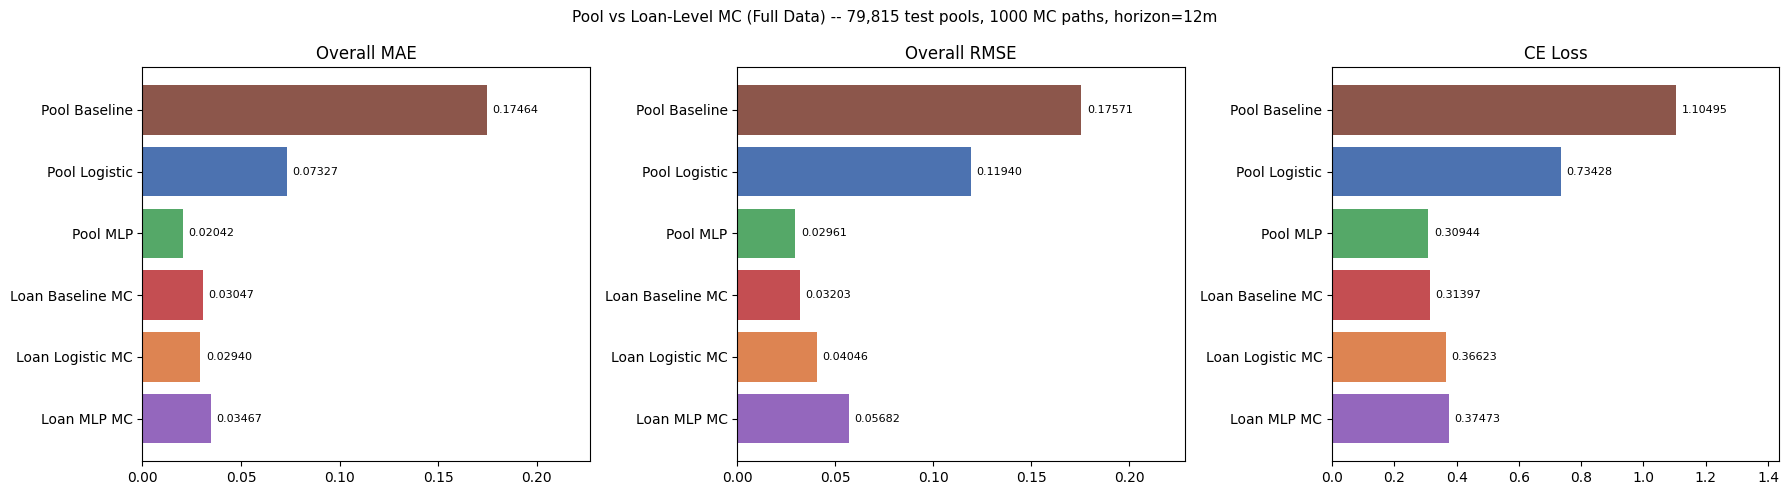

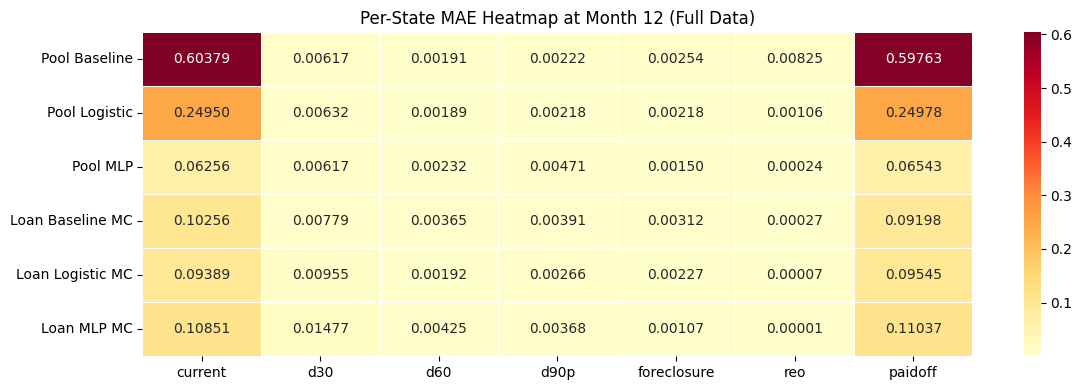

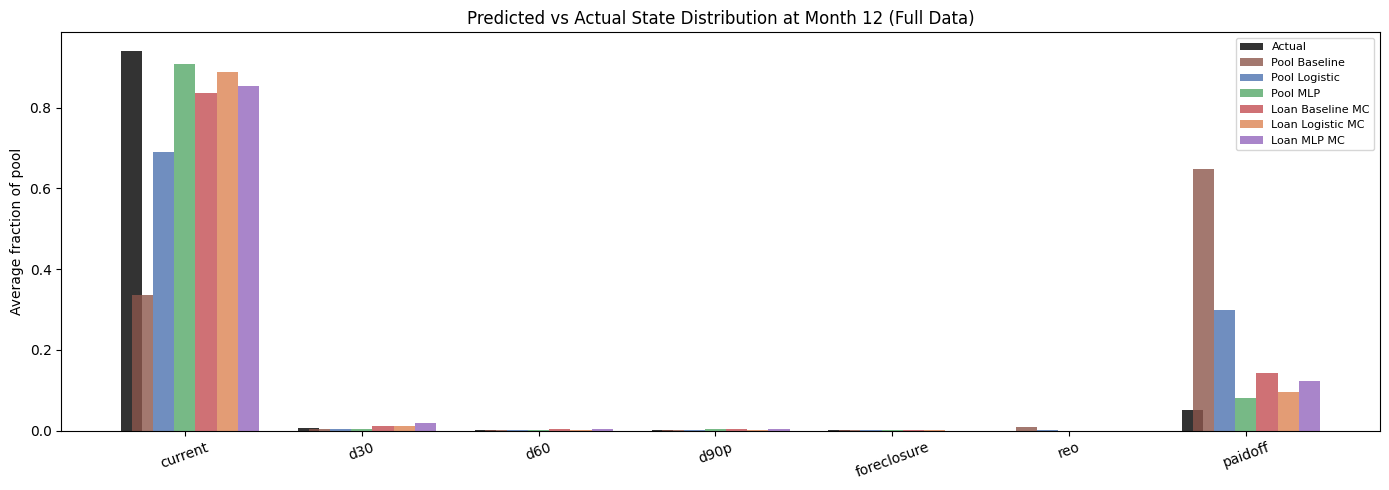

All figures saved.


In [ ]:
colours = ['#8c564b', '#4c72b0', '#55a868', '#c44e52', '#dd8452', '#9467bd']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mk, title in [
    (axes[0], 'MAE_overall',  'Overall MAE'),
    (axes[1], 'RMSE_overall', 'Overall RMSE'),
    (axes[2], 'CE_loss',      'CE Loss'),
]:
    vals = [all_metrics[m][mk] for m in model_names]
    bars = ax.barh(model_names, vals, color=colours)
    ax.bar_label(bars, fmt='%.5f', padding=4, fontsize=8)
    ax.set_xlim(0, max(vals)*1.30)
    ax.set_title(title)
    ax.invert_yaxis()
plt.suptitle(f'Pool vs Loan-Level MC (Full Data) -- {N_EVAL:,} test pools, '
             f'{N_MC_PATHS} MC paths, horizon={HORIZON}m', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig1_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

mae_mat = np.array([[all_metrics[m][f'MAE_{s}'] for s in STATE_NAMES]
                     for m in model_names])
fig2, ax2 = plt.subplots(figsize=(12, 4))
sns.heatmap(mae_mat, xticklabels=STATE_NAMES, yticklabels=model_names,
            annot=True, fmt='.5f', cmap='YlOrRd', ax=ax2, linewidths=0.5)
ax2.set_title('Per-State MAE Heatmap at Month 12 (Full Data)')
plt.tight_layout()
fig2.savefig(os.path.join(OUTPUT_DIR, 'fig2_per_state_mae.png'), dpi=150, bbox_inches='tight')
plt.show()

avg_true  = y_true_eval.mean(axis=0)
avg_preds = {m: p.mean(axis=0) for m, p in all_preds.items()}
x, width  = np.arange(N_STATES), 0.12
fig3, ax3 = plt.subplots(figsize=(14, 5))
ax3.bar(x - 2.5*width, avg_true, width, label='Actual', color='black', alpha=0.8)
for k, (m, col) in enumerate(zip(model_names, colours)):
    ax3.bar(x + (k-2)*width, avg_preds[m], width, label=m, color=col, alpha=0.8)
ax3.set_xticks(x); ax3.set_xticklabels(STATE_NAMES, rotation=20)
ax3.set_ylabel('Average fraction of pool')
ax3.set_title('Predicted vs Actual State Distribution at Month 12 (Full Data)')
ax3.legend(fontsize=8)
plt.tight_layout()
fig3.savefig(os.path.join(OUTPUT_DIR, 'fig3_state_dist.png'), dpi=150, bbox_inches='tight')
plt.show()
print('All figures saved.')


## Section 13 — Absolute Loan Counts on a Random Sample of Test Pools

In [ ]:
N_SAMPLE_POOLS = min(500, N_EVAL)
rng            = np.random.default_rng(SEED)
sample_idx     = rng.choice(N_EVAL, size=N_SAMPLE_POOLS, replace=False)
TOTAL_LOANS    = N_SAMPLE_POOLS * POOL_SIZE

print(f'\n{"="*80}')
print(f'TABLE 3 -- Absolute Loan Counts: {N_SAMPLE_POOLS} Randomly Sampled Test Pools')
print(f'          Total loans = {N_SAMPLE_POOLS} pools x {POOL_SIZE} loans = {TOTAL_LOANS:,}')
print(f'{"="*80}')

y_sample    = y_true_eval[sample_idx]
pred_sample = {m: p[sample_idx] for m, p in all_preds.items()}

def to_counts(frac_arr):
    return (frac_arr * POOL_SIZE).sum(axis=0).round(1)

actual_counts = to_counts(y_sample)

W2 = 18
hdr = f'{"State":<15}  {"Actual":>{W2}}'
for m in model_names:
    hdr += f'  {m[:W2]:>{W2}}'
print(hdr)
print('-' * (17 + (W2+2) * (len(model_names)+1)))

for i, s in enumerate(STATE_NAMES):
    row = f'{s:<15}  {actual_counts[i]:>{W2},.1f}'
    for m, p in pred_sample.items():
        pred_counts = to_counts(p)
        row += f'  {pred_counts[i]:>{W2},.1f}'
    print(row)

print('-' * (17 + (W2+2) * (len(model_names)+1)))

print(f'\n{"Gap vs Actual (loan counts)":}')
hdr2 = f'{"State":<15}  {"Actual":>{W2}}'
for m in model_names:
    hdr2 += f'  {m[:W2]:>{W2}}'
print(hdr2)
print('-' * (17 + (W2+2) * (len(model_names)+1)))

for i, s in enumerate(STATE_NAMES):
    row = f'{s:<15}  {actual_counts[i]:>{W2},.1f}'
    for m, p in pred_sample.items():
        gap = to_counts(p)[i] - actual_counts[i]
        sign = '+' if gap >= 0 else ''
        row += f'  {sign}{gap:>{W2-1},.1f}'
    print(row)

print('-' * (17 + (W2+2) * (len(model_names)+1)))

print(f'\n{"Total abs error (loans)":}')
row = f'{"all states":<15}  {"-":>{W2}}'
for m, p in pred_sample.items():
    total_gap = np.abs(to_counts(p) - actual_counts).sum()
    row += f'  {total_gap:>{W2},.1f}'
print(row)



TABLE 3 -- Absolute Loan Counts: 500 Randomly Sampled Test Pools
          Total loans = 500 pools x 100 loans = 50,000
State                        Actual       Pool Baseline       Pool Logistic            Pool MLP    Loan Baseline MC    Loan Logistic MC         Loan MLP MC
-------------------------------------------------------------------------------------------------------------------------------------------------------------
current                    46,970.0            16,778.1            34,703.0            45,330.4            41,858.6            44,500.8            42,774.2
d30                           253.0               173.9               237.6               257.9               534.8               582.3               921.1
d60                            64.0                45.2                45.9                71.5               156.4                53.8               196.5
d90p                           79.0                50.7                49.5               205.7  

## Section 14 — Save Outputs

In [ ]:
np.savez(os.path.join(OUTPUT_DIR, 'script6_predictions_full.npz'),
         pool_ids          = eval_pools,
         y_true            = y_true_eval,
         pool_baseline     = base_eval,
         pool_log_preds    = pool_log_ev,
         pool_mlp_preds    = pool_mlp_ev,
         loan_baseline_mc  = mc_base_ev,
         mc_log_preds      = mc_log_ev,
         mc_mlp_preds      = mc_mlp_ev,
         state_names       = np.array(STATE_NAMES))

with open(os.path.join(OUTPUT_DIR, 'script6_metrics_full.json'), 'w') as f:
    json.dump(all_metrics, f, indent=2)
print('Saved script6_metrics_full.json')

print('\n' + '='*60)
print('SCRIPT 6 (FULL DATA) COMPLETE')
print('='*60)
print(f'  Evaluation pools : {N_EVAL:,}')
print(f'  MC paths         : {N_MC_PATHS}')
print(f'  Horizon          : {HORIZON} months')
print()
print(f'  {"Model":<28} {"MAE":>8}  {"RMSE":>8}  {"CE":>8}')
print(f'  {"-"*56}')
for m in model_names:
    mt = all_metrics[m]
    print(f'  {m:<28} {mt["MAE_overall"]:>8.5f}  '
          f'{mt["RMSE_overall"]:>8.5f}  {mt["CE_loss"]:>8.5f}')
print(f'\n  Outputs: {OUTPUT_DIR}')


Saved script6_metrics_full.json

SCRIPT 6 (FULL DATA) COMPLETE
  Evaluation pools : 79,815
  MC paths         : 1000
  Horizon          : 12 months

  Model                             MAE      RMSE        CE
  --------------------------------------------------------
  Pool Baseline                 0.17464   0.17571   1.10495
  Pool Logistic                 0.07327   0.11940   0.73428
  Pool MLP                      0.02042   0.02961   0.30944
  Loan Baseline MC              0.03047   0.03203   0.31397
  Loan Logistic MC              0.02940   0.04046   0.36623
  Loan MLP MC                   0.03467   0.05682   0.37473

  Outputs: /content/drive/MyDrive/dissertation/script6_results_full


In [ ]:
print('\n' + '='*60)
print('ALL DONE — disconnecting runtime to stop compute-unit usage')
print('='*60)
print(f'  Final outputs saved to: {OUTPUT_DIR}')
print('  Disconnecting now...')

from google.colab import runtime
runtime.unassign()


ALL DONE — disconnecting runtime to stop compute-unit usage
  Final outputs saved to: /content/drive/MyDrive/dissertation/script6_results_full
  Disconnecting now...
